# Predicted force & torque — noise EDA

How noisy is the BEM's **predicted** force/torque output? Data: `processed_data/bem/bem_<ID>_seg_X.csv` (no header, 35 cols = 29 merged + 6 predicted). Cols 30-35 = predicted force x/y/z [N], torque x/y/z [Nm] (FLU body frame; verified in `simulator.cpp:56-59`, `Readme.md:72-77`).

Noise = **SNR (dB)** = `10*log10(var(lowpass_25) / var(residual))`. Dimensionless, so force and torque combine directly. **Lower = noisier.**

In [20]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utility as u
sys.path.append(str(Path.cwd().parent / 'analysis'))
import bem_baseline as baseline

u.PRED

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


['fx', 'fy', 'fz', 'tx', 'ty', 'tz']

## Per-flight SNR of the 6 predicted channels

SNR (dB) is dimensionless, so the 6 channels average directly (no normalization). Whole flight, segments concatenated. Lower SNR = noisier.

In [21]:
cache = 'pred_snr.csv'
if Path(cache).exists():
    snr = pd.read_csv(cache, index_col=0)
else:
    snr = pd.DataFrame({fid: {c: u.snr_db(u.load_bem_flight(fid)[c].to_numpy()) for c in u.PRED}
                        for fid in u.bem_flight_ids()}).T
    snr.to_csv(cache)
snr.shape

(95, 6)

In [22]:
score = snr.mean(axis=1).sort_values()
noisiest, calmest = score.index[0], score.index[-1]
print('noisiest (lowest SNR):', noisiest, '\ncalmest  (highest SNR):', calmest)
score

noisiest (lowest SNR): 2021-02-18-16-43-54 
calmest  (highest SNR): 2021-02-03-16-58-13


2021-02-18-16-43-54    31.971993
2021-02-05-14-19-34    35.362428
2021-02-23-14-33-04    36.839362
2021-02-18-17-09-50    37.342134
2021-02-23-14-41-07    37.573627
                         ...    
2021-02-05-15-04-42    46.692470
2021-02-18-17-03-20    47.341400
2021-02-23-10-50-42    47.417344
2021-02-23-10-52-00    47.618049
2021-02-03-16-58-13    47.896335
Length: 95, dtype: float64

## Plot noisiest vs calmest

In [25]:
def plot_pred(fid, title):
    df = u.load_bem_flight(fid)
    t = df['t'].to_numpy()
    fm, tm = baseline.measured(df.to_numpy())
    meas = np.column_stack([fm, tm])
    fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
    for i, c in enumerate(u.PRED):
        a = ax[i % 3, i // 3]
        a.plot(t, meas[:, i], lw=0.5, alpha=0.5, label='measured')
        a.plot(t, df[c].to_numpy(), lw=0.8, label='predicted')
        a.set_ylabel(c)
    ax[0, 0].set_title('force [N]'); ax[0, 1].set_title('torque [Nm]')
    ax[2, 0].set_xlabel('t [s]'); ax[2, 1].set_xlabel('t [s]')
    ax[0, 0].legend(loc='upper right', fontsize=7)
    fig.suptitle(title); fig.tight_layout()

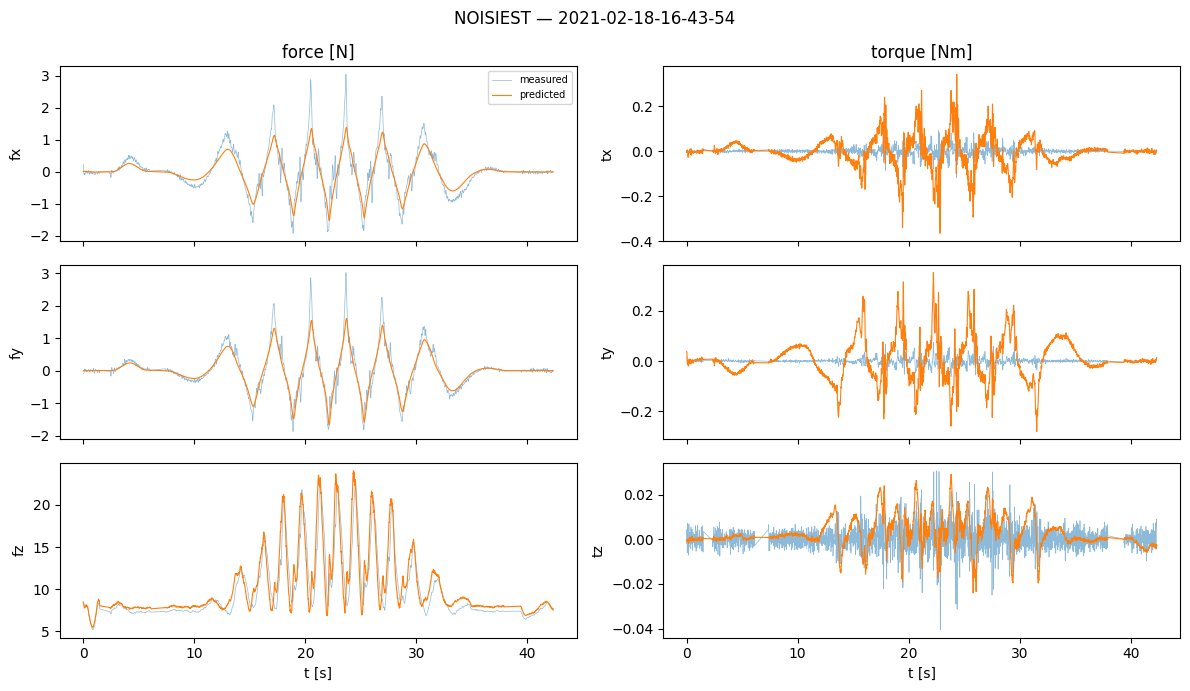

In [26]:
plot_pred(noisiest, f'NOISIEST — {noisiest}')

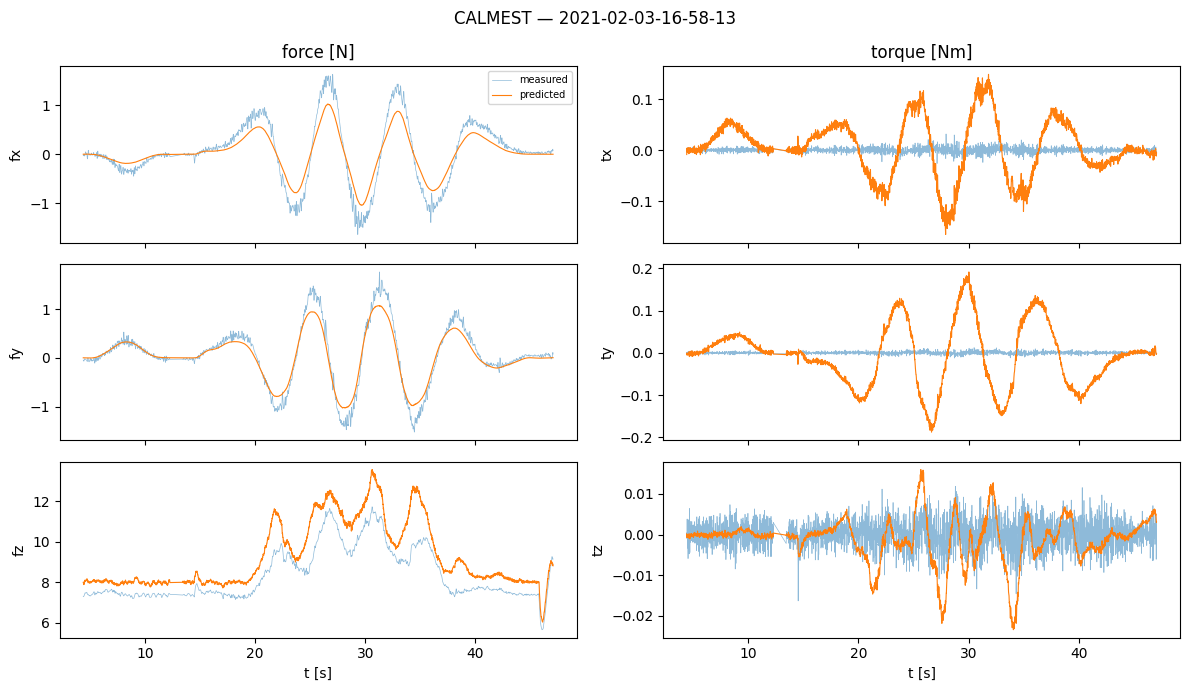

In [27]:
plot_pred(calmest, f'CALMEST — {calmest}')